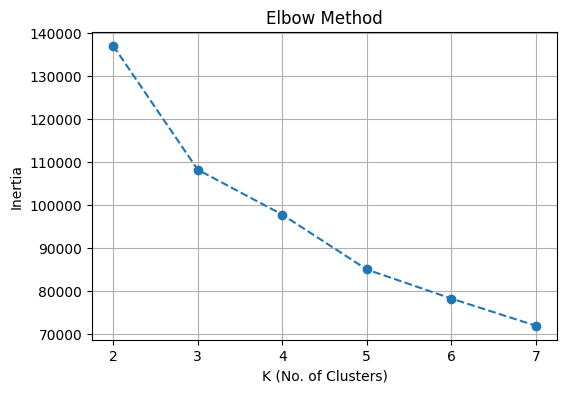

Cluster Assigned:
        City        Date    AQI  Cluster
0  Ahmedabad  2015-01-01  209.0        0
1  Ahmedabad  2015-01-02  209.0        1
2  Ahmedabad  2015-01-03  209.0        1
3  Ahmedabad  2015-01-04  209.0        1
4  Ahmedabad  2015-01-05  209.0        1


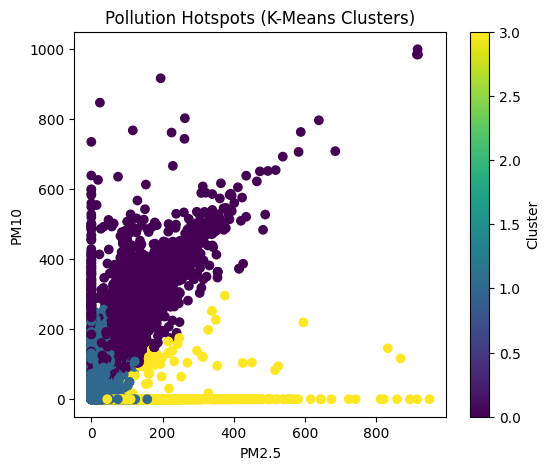

Saved: clustered_pollution_data.csv


In [1]:
# ======================================
# K-MEANS POLLUTION HOTSPOT CLUSTERING
# ======================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --------------------------
# 1. Load Dataset
# --------------------------
df = pd.read_csv("city_day.csv")

# Columns to use for clustering
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

df_clean = df[pollutants].fillna(df[pollutants].mean())

# --------------------------
# 2. Normalize Data
# --------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# --------------------------
# 3. Choose Optimal Clusters
# (Elbow Method)
# --------------------------
inertia = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, "o--")
plt.title("Elbow Method")
plt.xlabel("K (No. of Clusters)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# --------------------------
# 4. Fit K-Means
# --------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

print("Cluster Assigned:")
print(df[["City", "Date", "AQI", "Cluster"]].head())

# --------------------------
# 5. Visualize Hotspots
# --------------------------
plt.figure(figsize=(6,5))
plt.scatter(df["PM2.5"], df["PM10"], c=df["Cluster"], cmap="viridis")
plt.xlabel("PM2.5")
plt.ylabel("PM10")
plt.title("Pollution Hotspots (K-Means Clusters)")
plt.colorbar(label="Cluster")
plt.show()

# --------------------------
# 6. Save clustered data
# --------------------------
df.to_csv("clustered_pollution_data.csv", index=False)
print("Saved: clustered_pollution_data.csv")
